### 1. Import Libraries 
To build the breast cancer classification model, several essential Python libraries are imported. The os library is used for file handling and accessing image folders, while cv2 (OpenCV) helps in reading and preprocessing images. numpy handles numerical data efficiently, and skimage.feature.hog extracts important texture and shape features using the HOG descriptor. The scikit-learn modules provide tools for model training (RandomForestClassifier), encoding (LabelEncoder), and performance evaluation (accuracy_score, confusion_matrix, classification_report). tqdm is used to visualize loop progress, matplotlib.pyplot and seaborn are used for plotting and displaying images, and joblib is used to save and load the trained model for later use.

In [1]:

import os
import cv2
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import hog
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### 2. Define Paths
In this step, the paths for the training and testing datasets are defined. These directories contain the breast cancer image data categorized into different folders, such as Benign and Malignant. The train_dir and test_dir variables specify the file locations where the images are stored on the system. These paths will later be used to load and preprocess the images for feature extraction and model training.

In [2]:

train_dir = r'C:\Users\rizwa\Desktop\Minor Project\dataset'
test_dir = r'C:\Users\rizwa\Desktop\Minor Project\dataset'

### 3. Extract Features
In this step, a helper function named extract_features() is defined to process all images in the dataset and extract their features for model training. The function reads each image from the given directory, resizes it to 128×128 pixels, and converts it to grayscale for consistent processing. Then, it applies the Histogram of Oriented Gradients (HOG) technique to extract important texture and shape features, which are effective in distinguishing between benign and malignant breast tissue images. The extracted features are stored in the features list, while the corresponding class labels are stored in the labels list. The function finally returns both as NumPy arrays for further use in model training.

In [3]:

def extract_features(directory):
    features, labels = [], []
    for label in os.listdir(directory):
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_name in tqdm(os.listdir(class_dir), desc=f"Processing {label}"):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (128, 128))
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # HOG feature extraction
                hog_features, _ = hog(gray, orientations=9, pixels_per_cell=(8,8),
                                      cells_per_block=(2,2), block_norm='L2-Hys',
                                      visualize=True)
                features.append(hog_features)
                labels.append(label)
            except Exception as e:
                print(f"Error: {e}")
    return np.array(features), np.array(labels)

In [4]:

print("Extracting features from training data")
X_train, y_train = extract_features(train_dir)

print("\nExtracting features from test data")
X_test, y_test = extract_features(test_dir)

print("\nFeature extraction completed.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Extracting features from training data


Processing normal: 100%|██████████| 798/798 [00:45<00:00, 17.68it/s]



Extracting features from test data


Processing normal: 100%|██████████| 798/798 [00:46<00:00, 17.28it/s]



Feature extraction completed.
Training samples: 2531
Testing samples: 2531


### 4. Encode Labels
After extracting features from the images, the class labels (such as Benign and Malignant) need to be converted into numeric form so that the machine learning model can process them. This is done using Label Encoding from the sklearn.preprocessing module. The LabelEncoder() assigns a unique integer value to each label — for instance, Benign = 0 and Malignant = 1.

In [5]:

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

### 5. Train Random Forest Model
Random Forest Classifier is trained using the extracted HOG features from the breast cancer dataset. The model is initialized with 200 decision trees (n_estimators=200) and a fixed random state (42) to ensure reproducibility of results. The Random Forest algorithm combines the predictions of multiple decision trees to improve accuracy and reduce overfitting. The fit() function is then used to train the model on the training data (X_train) and the encoded labels (y_train_enc).

In [6]:

print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train_enc)
print("Model training complete!")


Training Random Forest model...
Model training complete!


### 6. Evaluate Model
Once the model has been trained, it is tested on the unseen data to evaluate its performance. The trained Random Forest model predicts the labels for the test set using the predict() function. These predictions (y_pred) are then compared with the actual encoded labels (y_test_enc) to calculate the accuracy of the model using accuracy_score(). Additionally, a classification report is generated, which provides detailed metrics such as precision, recall, and F1-score for each class (e.g., Benign and Malignant). These evaluation metrics help in understanding how well the model can distinguish between the two classes.

In [7]:

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test_enc, y_pred)
print(f"\n Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


 Accuracy: 99.96%

Classification Report:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00       891
   malignant       1.00      1.00      1.00       842
      normal       1.00      1.00      1.00       798

    accuracy                           1.00      2531
   macro avg       1.00      1.00      1.00      2531
weighted avg       1.00      1.00      1.00      2531



### 7. Confusion Matrix
To better visualize the performance of the trained model, a confusion matrix is plotted. The confusion matrix shows the number of correct and incorrect predictions made by the Random Forest classifier for each class. Using confusion_matrix() from sklearn.metrics, the matrix is computed by comparing the actual test labels (y_test_enc) with the predicted labels (y_pred). The matrix is then visualized using Seaborn’s heatmap, where each cell represents the count of predictions. The diagonal elements indicate correct classifications, while off-diagonal elements represent misclassifications. This visualization helps in understanding how accurately the model distinguishes between Benign and Malignant cases.

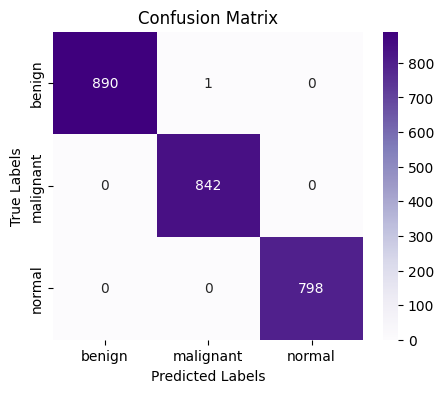

In [8]:

cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


### 8. ROC Curve
The ROC (Receiver Operating Characteristic) curve evaluates the performance of the Random Forest classifier by plotting the True Positive Rate against the False Positive Rate for each class. The AUC (Area Under Curve) measures how well the model distinguishes between classes. Higher AUC values indicate better classification performance. This visualization helps assess the model’s overall accuracy and discrimination ability across all classes.

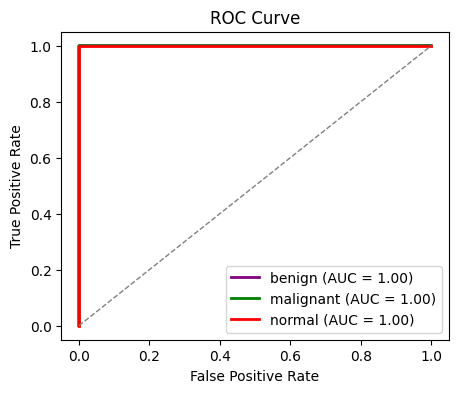

In [9]:

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = [0,1,2]
y_test_enc = label_binarize(y_test_enc, classes=classes)

y_score = rf_model.predict_proba(X_test)

plt.figure(figsize=(5,4))
colors = ['purple', 'green', 'red']
for i, color in zip(range(len(classes)), colors):
    fpr, tpr, _ = roc_curve(y_test_enc[:,i], y_score[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### 8. Save Model
After successful training and evaluation, the final step is to save the trained model and the label encoder for future use. This allows the model to be reused for prediction without retraining every time. Using the joblib.dump() function, the trained Random Forest model is saved as "breast_cancer_rf_model.pkl" and the LabelEncoder as "label_encoder.pkl".

In [10]:

joblib.dump(rf_model, "breast_cancer_rf_model.pkl")
joblib.dump(le, "label_encoder.pkl")
print("\n Model and label encoder saved successfully!")


 Model and label encoder saved successfully!


### 9. Prediction Function
In this step, a function named predict_and_show_image() is created to allow the user to input a new breast cancer image and see its classification result. The function first checks whether the given image path exists. It then reads the image using OpenCV, resizes it to 128×128 pixels, and converts it to grayscale to maintain consistency with the training data. The HOG (Histogram of Oriented Gradients) features are extracted from the image and reshaped to match the model’s input format. The trained Random Forest model predicts the class of the image (either Benign or Malignant), and the LabelEncoder decodes the numeric prediction back into text.

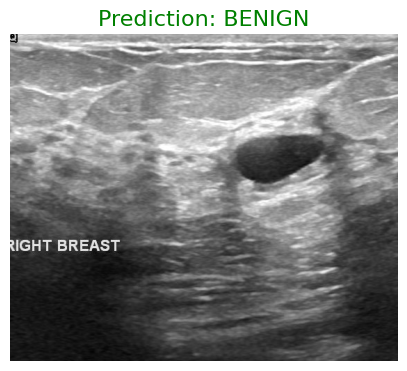


 Predicted Class: BENIGN


In [11]:

def predict_and_show_image(img_path):
    if not os.path.exists(img_path):
        print("Image file not found!")
        return

    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Extract HOG features
    hog_features, _ = hog(gray, orientations=9, pixels_per_cell=(8,8),
                          cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
    hog_features = hog_features.reshape(1, -1)

    # Predict
    pred = rf_model.predict(hog_features)
    label = le.inverse_transform(pred)[0]

    # Show image with label
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Prediction: {label.upper()}", fontsize=16, color=('green' if label.lower() == 'benign' else 'red'))
    plt.show()

    print(f"\n Predicted Class: {label.upper()}")

# User Input
img_path = input("\n Enter the path to the image you want to classify: ").strip()
if img_path:
    predict_and_show_image(img_path)
else:
    print(" No image path entered.")

In [12]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']